In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
%matplotlib qt

from fovmap.plots_utils import visualize_lens_dir, plot_cone, plot_cone_vert
from fovmap.file_utils import (
    parse_lens_dir_csv_file,
    rotate_vectors,
    load_manual_hex_grid_face_list,
    create_intersect_df
    )
from fovmap.vector_cone_intersect import vector_cone_intersection
from fovmap.surface_plot import (
    complete_cone_surface_apex_neg_z,
    cone_surface_apex_neg_z,
    cone_surface_apex_neg_z_w_blckd_ngl
    )
from fovmap.face_utils import (
    categorize_face,
    plot_hexagonal_surfaces_from_df,
    project_points_on_surface
)
from fovmap.deformation_metrics import (
    calculate_metrics
)
from fovmap.vertices_filtering import filter_vert_z_bound, filter_vert_z_bound_w_none
from fovmap import FILES_PATH, CONFIG_PATH

## Get Vertices

In [31]:
# Load the lens directory
lens_dir_path = FILES_PATH / 'ommatidia_lens_dir.csv'
# Fly facing positive x direction
vertices = parse_lens_dir_csv_file(lens_dir_path)
original_vertices_dict = {
    ind: vertices[ind].copy() for ind in range(len(vertices))
}
viewing_dir = np.array([1, 0, 0])
# Cartesian coordinates rotation
rx = 0
ry = 0
rz = 0
title = f"rx_{rx}_ry_{ry}_rz_{rz}"
# Rotate the lens
if rx or ry or rz:
    rotated_vertices = rotate_vectors(vertices, rx, ry, rz)
    viewing_dir = rotate_vectors(viewing_dir, rx, ry, rz)
    rotated_vertices_dict = {
        ind: vertices[ind].copy() for ind in range(len(vertices))
    }
else:
    rotated_vertices = vertices

In [32]:
visualize_lens_dir(rotated_vertices, viewing_dir)

## Get Cone

In [23]:
cone_config_path = CONFIG_PATH / 'cone_config.json'
with open(cone_config_path, 'r') as f:
    cone_config = json.load(f)

## Cone and Vertices Intersection

In [24]:
pos_height_lim = 100
resolution = 500

In [25]:
intersect_point, ommatidia_to_intersect = vector_cone_intersection(
    radius=cone_config['radius'],
    height=cone_config['height'],
    vertices=rotated_vertices
)

In [26]:
cone_x, cone_y, cone_z = complete_cone_surface_apex_neg_z(
   radius=cone_config['radius'],
   cone_angle_deg=cone_config['cone_angle_deg'],
   height=cone_config['height'],
   pos_height_lim=pos_height_lim,
   z_base_offset=0,
   resolution=resolution
   )
filtered_vert = filter_vert_z_bound(intersect_point.values(), [-cone_config["height"], pos_height_lim])

In [27]:
cutoff_cone_x, cutoff_cone_y, cutoff_cone_z = cone_surface_apex_neg_z(
   radius=cone_config['radius'],
   cone_angle_deg=cone_config['cone_angle_deg'],
   angle_revolution_deg=cone_config['angle_revolution_deg'],
   angle_offset_deg=cone_config['angle_offset_deg'],
   height=cone_config['height'],
   height_cutoff=cone_config['height_cutoff'],
   z_base_offset=0,
   resolution=resolution
)
cutoff_filtered_vert = filter_vert_z_bound(intersect_point.values(), [-cone_config["height_cutoff"], 0])


In [28]:
real_cone_x, real_cone_y, real_cone_z = cone_surface_apex_neg_z_w_blckd_ngl(
    radius=cone_config['radius'],
    cone_angle_deg=cone_config['cone_angle_deg'],
    angle_revolution_deg=cone_config['angle_revolution_deg'],
    angle_offset_deg=cone_config['angle_offset_deg'],
    height=cone_config['height'],
    height_cutoff=cone_config['height_cutoff'],
    z_base_offset=0,
    resolution=resolution,
    blocked_angle_deg=55,
    outer_blocked_angle_deg=25
)

In [29]:
cone_no_lim_fig, cone_no_lim_ax = plot_cone(cone_x, cone_y, cone_z)
cutoff_cone_fig, cutoff_cone_ax = plot_cone(cutoff_cone_x, cutoff_cone_y, cutoff_cone_z)
real_cone_fig, real_cone_ax = plot_cone(real_cone_x, real_cone_y, real_cone_z)
plot_cone_vert(cone_x, cone_y, cone_z, filtered_vert)
plot_cone_vert(cutoff_cone_x, cutoff_cone_y, cutoff_cone_z, filtered_vert)
plot_cone_vert(real_cone_x, real_cone_y, real_cone_z, cutoff_filtered_vert)

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: title={'center': 'Intersection of Lens Directions and Cone'}, xlabel='X', ylabel='Y', zlabel='Z'>)

## Classify Faces

In [11]:
mhg_path = FILES_PATH / 'ommatidia_hex_grid.json'
face_list = load_manual_hex_grid_face_list(vertices, mhg_path)
surface_df = pd.DataFrame.from_dict({ind: {"face_indexes": face} for ind, face in enumerate(face_list)}).T
surface_df["om_vertices"] = surface_df["face_indexes"].apply(lambda x: [ommatidia_to_intersect[i]["om_dir"] for i in x])
surface_df["om_intersect"] = surface_df["face_indexes"].apply(lambda x: [ommatidia_to_intersect[i]["om_int"] for i in x])
surface_df["om_intersect_w_cone"] = surface_df["om_intersect"].apply(lambda x: filter_vert_z_bound_w_none(x, [-cone_config["height_cutoff"], 0]))
surface_df["n_cone_intersect"] = surface_df["om_intersect_w_cone"].apply(lambda x: len([vert for vert in x if vert[0] is not None]))

In [12]:
surface_df = surface_df[surface_df["n_cone_intersect"] > 0]
surface_df["om_no_intersect_w_cone"] = surface_df.apply(lambda x: [x["om_intersect"][i] if x["om_intersect"][i] not in x["om_intersect_w_cone"] else [None, None, None] for i in range(len(x["om_intersect"]))], axis=1)

## Handle surfaces with partial intersection

In [13]:
surface_df["om_no_intersect_w_cone_projeted"] = surface_df.apply(lambda x: project_points_on_surface(cutoff_cone_x, cutoff_cone_y, cutoff_cone_z, x["om_no_intersect_w_cone"]), axis=1)

In [14]:
surface_df["intersect_face_for_plot"] = surface_df.apply(lambda x: [
    a if a[0] is not None else b
    for a, b in zip(x["om_intersect_w_cone"], x["om_no_intersect_w_cone_projeted"])
    ], axis=1)
surface_df["n_inter_plot"] = surface_df["intersect_face_for_plot"].apply(lambda x: len(x))

## Calculate Faces Deformation


In [15]:
surface_df[["area_distortion", "max_edge_length_variation", "max_angle_deviation", "aspect_ratio_change", "hausdorff_distance"]] = surface_df.apply(lambda x: calculate_metrics(x["om_vertices"], x["om_intersect"]), axis=1, result_type="expand")

In [16]:
surface_df["log_area_distortion"] = np.log(surface_df["area_distortion"])

## Surface Rendering per metric

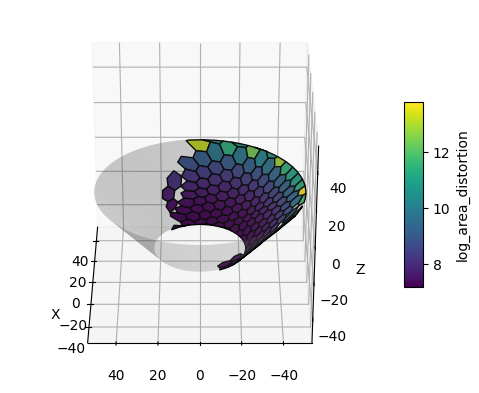

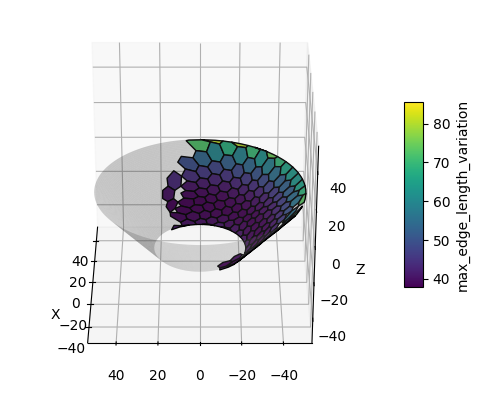

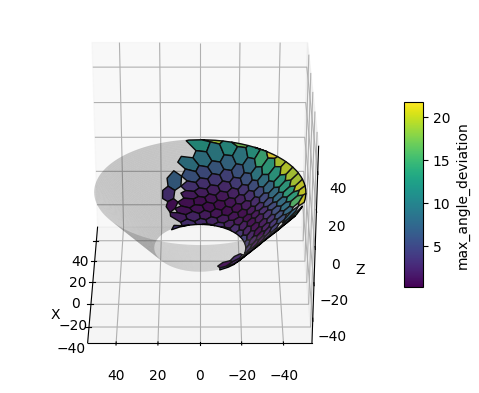

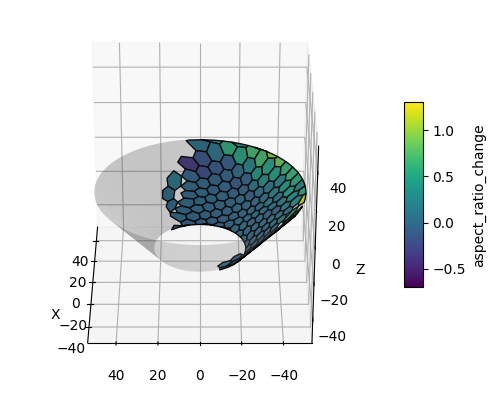

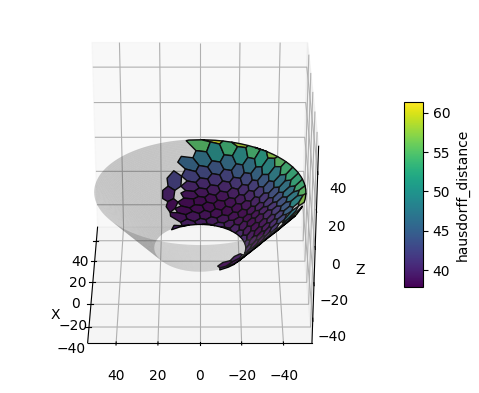

In [17]:
metric_list = ["log_area_distortion", "max_edge_length_variation", "max_angle_deviation", "aspect_ratio_change", "hausdorff_distance"]
for metric in metric_list:
    fig, ax = plot_cone(cutoff_cone_x, cutoff_cone_y, cutoff_cone_z)
    plot_hexagonal_surfaces_from_df(surface_df, "intersect_face_for_plot", hue_col = metric, fig=fig, ax=ax)